The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Epoch 0 with train loss: 0.3072037313381831 and eval loss: 0.10023759437077072
Epoch 1 with train loss: 0.1373470855752627 and eval loss: 0.10071851515575596
Epoch 2 with train loss: 0.1353610478838285 and eval loss: 0.09996126077907241
Epoch 3 with train loss: 0.13363733420769375 and eval loss: 0.10984659802330576
Epoch 4 with train loss: 0.12997221142053605 and eval loss: 0.10510485121251448
Epoch 5 with train loss: 0.11745780487855276 and eval loss: 0.09161758690100649
Epoch 6 with train loss: 0.10663079460461934 and eval loss: 0.09841032678504354
Epoch 7 with train loss: 0.08713643570741017 and eval loss: 0.09614235144513457
Epoch 8 with train loss: 0.09449962158997853 and eval loss: 0.1018152832782463
Epoch 9 with train loss: 0.0897373403608799 and eval loss: 0.09167883844803208
Epoch 10 with train loss: 0.08466741745670636 and eval loss: 0.09292092196562368
Epoch 11 with train loss: 0.08087150

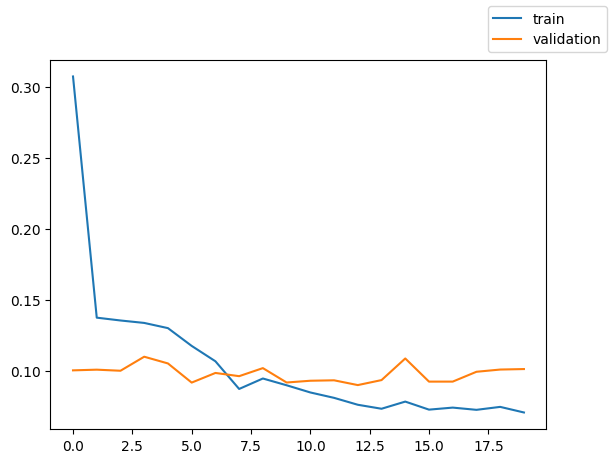

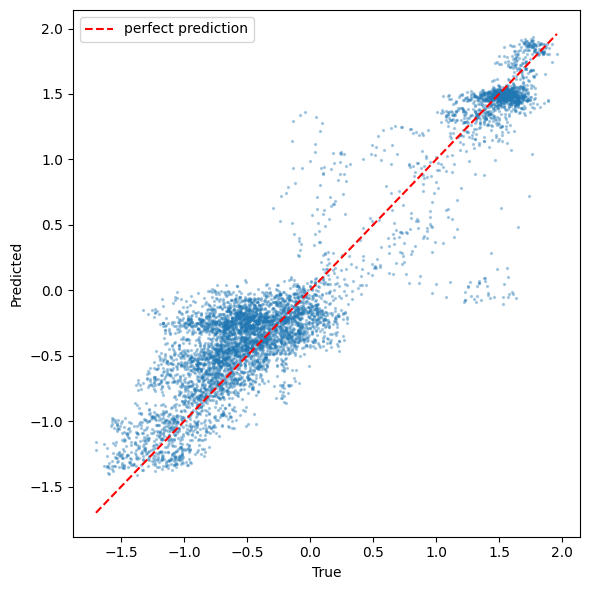

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import pickle

%load_ext autoreload
%autoreload 2

from data_helpers import prepare_this_data, torchify_this_data
from model_stuff import model_setup

df = pd.read_csv('../data/CESMDataset_Try.csv')

target_col = 'PD_200m'
feature_cols = ['SFWF', 'AMOC']
lag = 100
horizon = 40
n = len(df)
train_cut_1 = 5000
train_cut_2 = 11000
batch_size = 128

X_train_lag, y_train_lag, X_eval_lag, y_eval_lag, y_scaler, x_scaler = prepare_this_data(df, 
                                                                                        target_col, 
                                                                                        feature_cols,
                                                                                        train_cut_1,
                                                                                        train_cut_2,
                                                                                        lag,
                                                                                        horizon)

X_train_t, y_train_t, train_loader, X_eval_t, y_eval_t, eval_loader = torchify_this_data(batch_size, 
                                                                                                    X_train_lag, 
                                                                                                    y_train_lag,  
                                                                                                    X_eval_lag, 
                                                                                                    y_eval_lag)
device = "cpu"
n_epochs = 20

params = {
    'n_features': len(feature_cols),
    'hidden_size': 64,
    'num_layers': 1,
    'dropout': 0.0,
    'lr': 1e-3,
    'loss_fn': nn.MSELoss()
}

NN_PD_200m, train_losses, eval_losses = model_setup(device, params, n_epochs, train_loader, eval_loader, X_eval_t, y_eval_lag)

torch.save({
    'state_dict': NN_PD_200m.state_dict(),
    'config': {
        'n_features': len(feature_cols),
        'hidden_size': 64,
        'num_layers': 1,
        'dropout': 0.0,
    },
}, 'PD_200m_model.pth')

with open('scalers_PD_200m.pkl', 'wb') as f:
    pickle.dump({'y_scaler': y_scaler, 'x_scaler': x_scaler}, f)